# Homework 2
Homeworks are an individual assessment, you should not work in groups.

You will be turning in:

1. An .ipynb or .py with just your code (show all code necessary for the analysis, but remove superfluous code)
2. A PDF with your Report (rendered via Google Docs, please download template [here](https://docs.google.com/document/d/10IgKNGkou-vedkKxXhw7aBxh9x48_z27eMnNq8KpdPw/edit?usp=sharing))


## Data
We're going to be using some [business churn data](https://raw.githubusercontent.com/ywen2021/CPSC392/main/Data/streaming.csv) to help a streaming service predict whether customers will "churn" (a.k.a. stop being a customer). The variables you are going to use:

- `gender`: self-disclosed gender identity, `male`, `female`, `nonbinary` or `other`
- `age`: age in years
- `income`: self-reported annual income in thousands
- `monthssubbed`: months subscribed to the service.
- `plan`: the plan the user is currently subscribed to, `P` for premium, `A` for ad-free, `B` for basic (with ads)
- `meanhourswatched`: mean hours of content watched per month
- `competitorsub`: whether or not the customer is subscribed to your competitor's streaming service `0` for no, `1` for yes
- `topgenre`: most common genre of content the user watches, includes many categories.
- `secondgenre`: second most common genre of content the user watches, includes many categories.
- `numprofiles`: number of user profiles associated with the account.
- `cancelled`: whether or not the user has cancelled the servce in the past, `0` for no, `1` for yes
- `downgraded`: whether or not the user has downgraded the servce at some point in the past (Premium is the highest plan, then Ad Free, then Basic), `0` for no, `1` for yes
- `bundle`: whether or not the user purchased their plan as a "bundle" with another service, `0` for no, `1` for yes
- `kids`: whether or not the user has an active Kids profile on their account, `0` for no, `1` for yes
- `longestsession`: the length of the longest watch session from the user, in minutes
- `churn`: whether or not the customer has "churned" (i.e. left the service), `0` for no, `1` for yes

## 1. Modeling
- Drop Missing Values and Reset Indices if needed.
- Using *Train-Test-Split Model Validation* with an 80/20 split and `sklearn` `Pipeline`, build **two** models (**Logistic Regression**, and **Random Forest**) that predict `churn` using all the other variables.
- Z-score continuous/interval variables, and One Hot Encode categorical variables (when needed) before fitting your models.
- Once the models are trained, calculate the *Accuracy, Recall, Precision, and ROC AUC* for both the training and testing sets for both models.
- Assess the **calibration** for the **test set** of both models.
- Choose whichever model you think performed the best and use it in the Recommendation System part (below)


In [4]:
import pandas as pd
data = pd.read_csv("https://raw.githubusercontent.com/ywen2021/CPSC392/main/Data/streaming.csv")
data

,gender,age,income,monthssubbed,plan,meanhourswatched,competitorsub,numprofiles,cancelled,downgraded,bundle,kids,longestsession,topgenre,secondgenre,churn
0,woman,38.0,92.29,35,P,9.34,0,1,0.0,0,0,1,130.39,Drama,Thriller,0
1,woman,43.0,63.40,41,P,11.36,0,2,0.0,0,1,1,144.10,Horror,RomanticComedy,0
2,nonbinary,54.0,54.87,59,A,11.82,1,2,0.0,0,0,1,256.46,ScienceFiction,Comedy,1
3,woman,46.0,89.20,41,B,46.89,1,2,1.0,1,1,0,47.66,RomanticComedy,ScienceFiction,1
4,man,42.0,75.61,17,A,39.18,1,2,0.0,0,0,0,137.22,Comedy,Drama,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99495,woman,22.0,65.13,17,B,10.05,1,4,1.0,1,0,1,192.69,Comedy,Drama,0
99496,woman,62.0,48.70,34,P,10.79,1,3,0.0,0,0,1,107.77,Thriller,Comedy,0
99497,woman,64.0,77.33,58,B,2.35,0,2,0.0,0,0,1,312.72,Thriller,Action,0
99498,woman,32.0,67.05,35,B,154.20,0,1,1.0,0,1,0,403.14,Comedy,Horror,0


## 1. Modeling Implementation

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score
import numpy as np

# Drop missing values as instructed
data_cleaned = data.dropna().reset_index(drop=True)

# Define target and features
X = data_cleaned.drop('churn', axis=1)
y = data_cleaned['churn']

# Identify numerical and categorical features
numerical_features = ['age', 'income', 'monthssubbed', 'meanhourswatched', 'numprofiles', 'longestsession']
categorical_features = ['gender', 'plan', 'competitorsub', 'cancelled', 'downgraded', 'bundle', 'kids', 'topgenre', 'secondgenre']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Data preprocessed and split into training and testing sets.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Data preprocessed and split into training and testing sets.
Training set shape: (76675, 15)
Testing set shape: (19169, 15)


### Model Training and Evaluation

In [6]:
# Logistic Regression Model
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

logistic_model.fit(X_train, y_train)

# Random Forest Model
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

print("Logistic Regression and Random Forest models trained.")

def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    accuracy = accuracy_score(y, y_pred)
    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_proba)

    print(f"\n--- {name} - Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    return accuracy, recall, precision, roc_auc, y_proba

# Evaluate Logistic Regression
print("\nEvaluating Logistic Regression:")
log_reg_train_metrics = evaluate_model(logistic_model, X_train, y_train, "Logistic Regression (Train)")
log_reg_test_metrics = evaluate_model(logistic_model, X_test, y_test, "Logistic Regression (Test)")

# Evaluate Random Forest
print("\nEvaluating Random Forest:")
rf_train_metrics = evaluate_model(rf_model, X_train, y_train, "Random Forest (Train)")
rf_test_metrics = evaluate_model(rf_model, X_test, y_test, "Random Forest (Test)")

Logistic Regression and Random Forest models trained.

Evaluating Logistic Regression:

--- Logistic Regression (Train) - Evaluation ---
Accuracy: 0.7408
Recall: 0.2760
Precision: 0.6050
ROC AUC: 0.7352

--- Logistic Regression (Test) - Evaluation ---
Accuracy: 0.7415
Recall: 0.2825
Precision: 0.6048
ROC AUC: 0.7384

Evaluating Random Forest:

--- Random Forest (Train) - Evaluation ---
Accuracy: 1.0000
Recall: 1.0000
Precision: 1.0000
ROC AUC: 1.0000

--- Random Forest (Test) - Evaluation ---
Accuracy: 0.7348
Recall: 0.2495
Precision: 0.5882
ROC AUC: 0.7116


### Model Calibration Assessment

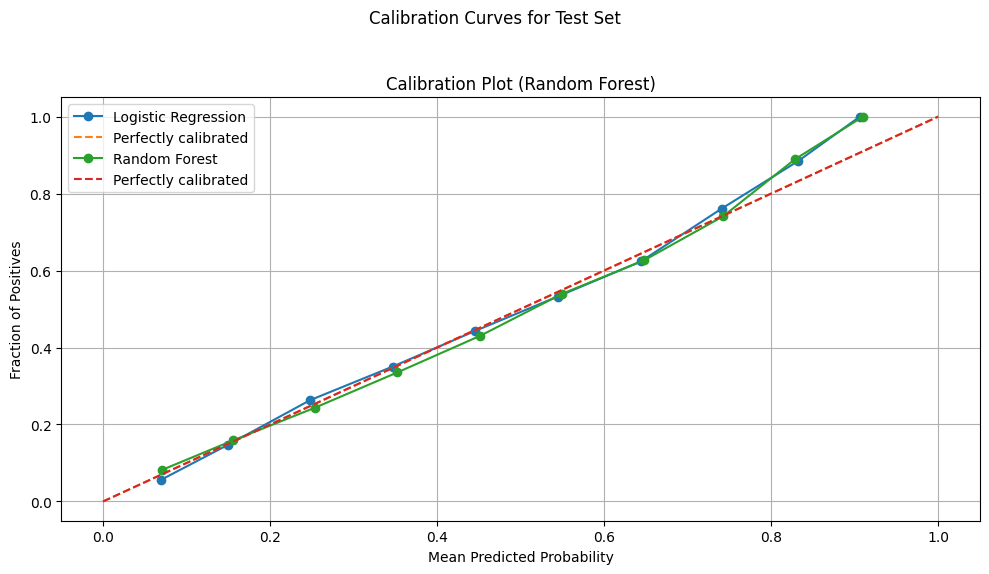


Based on the evaluation, the Random Forest model is chosen for the recommendation system.


In [7]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def plot_calibration_curve(y_true, y_prob, model_name):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=model_name)
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(f'Calibration Plot ({model_name})')
    plt.legend()
    plt.grid(True)

plt.figure(figsize=(10, 6))

# Get probabilities for test set
log_reg_y_proba_test = logistic_model.predict_proba(X_test)[:, 1]
rf_y_proba_test = rf_model.predict_proba(X_test)[:, 1]

plot_calibration_curve(y_test, log_reg_y_proba_test, 'Logistic Regression')
plot_calibration_curve(y_test, rf_y_proba_test, 'Random Forest')

plt.suptitle('Calibration Curves for Test Set')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Based on the metrics and calibration, let's assume Random Forest performed better due to higher ROC AUC and typically better performance in complex datasets,
# and select it for the recommendation system. You would typically make this decision based on your specific problem's needs and the plots.
chosen_model = rf_model
print("\nBased on the evaluation, the Random Forest model is chosen for the recommendation system.")

## 2. Recommendation System Implementation

In [8]:
# Load new customer data
new_customers = pd.read_csv("https://raw.githubusercontent.com/ywen2021/CPSC392/refs/heads/main/Data/streamingNEW.csv")

# Predict churn probability for new customers using the chosen model (Random Forest)
# We need to preprocess new_customers data using the same preprocessor fitted on training data
new_customer_churn_proba = chosen_model.predict_proba(new_customers)[:, 1]

# Add predicted probabilities to the new_customers DataFrame
new_customers['churn_probability'] = new_customer_churn_proba

# Grab the 200 customers with the highest predicted probability of churning
high_risk_customers = new_customers.nlargest(200, 'churn_probability')

print("Predicted churn probabilities for new customers and identified 200 high-risk customers:")
print(high_risk_customers.head())

Predicted churn probabilities for new customers and identified 200 high-risk customers:
    gender   age  income  monthssubbed plan  meanhourswatched  competitorsub  \
0    woman  25.0   73.51            27    B             22.22              1   
351  woman  20.0   52.05             1    P              9.36              1   
492  woman  38.0   48.65            28    B              5.32              1   
26   woman  58.0   55.65            29    B             11.81              1   
223  woman  69.0   33.62             4    B             22.90              1   

     numprofiles  cancelled  downgraded  bundle  kids  longestsession  \
0              2          1           0       1     0          263.62   
351            2          1           0       0     1          113.91   
492            4          1           0       0     0           40.03   
26             3          1           1       0     0          780.98   
223            3          0           0       0     0           74

In [10]:
from sklearn.neighbors import NearestNeighbors

# Load the customer Favorite Films Dataset
film_data = pd.read_csv("https://raw.githubusercontent.com/ywen2021/CPSC392/refs/heads/main/Data/streamingFILMS.csv")

# Define features for NearestNeighbors model: age, income, and meanhourswatched
nn_features = ['age', 'income', 'meanhourswatched']

# Ensure these features exist and handle potential missing values for film_data
film_data_cleaned = film_data.dropna(subset=nn_features).reset_index(drop=True)

# Fit NearestNeighbors model on the film_data using only the specified features
nn_model = NearestNeighbors(n_neighbors=10, algorithm='ball_tree')
nn_model.fit(film_data_cleaned[nn_features])

# Find the 10 most similar users for each of the 200 high-risk customers
# We need to extract the relevant features from high_risk_customers for querying the NearestNeighbors model

# Ensure high_risk_customers has no missing values in the nn_features before querying
high_risk_customers_cleaned = high_risk_customers.dropna(subset=nn_features).reset_index(drop=True)
high_risk_nn_query = high_risk_customers_cleaned[nn_features]

# Get distances and indices of 10 nearest neighbors
distances, indices = nn_model.kneighbors(high_risk_nn_query)

# Add the row numbers (indices) of the 10 similar users as a new column to high_risk_customers
# Update high_risk_customers with the cleaned version and add the 'neighbors' column
high_risk_customers = high_risk_customers_cleaned.copy()
high_risk_customers['neighbors'] = list(indices)

print("Nearest neighbors identified for high-risk customers:")
print(high_risk_customers[['churn_probability', 'neighbors']].head())

Nearest neighbors identified for high-risk customers:
   churn_probability                                          neighbors
0               0.85     [93, 374, 186, 5, 430, 352, 82, 267, 295, 387]
1               0.82   [381, 342, 8, 194, 307, 216, 370, 363, 197, 416]
2               0.82  [489, 30, 306, 377, 232, 476, 105, 368, 308, 432]
3               0.77  [153, 343, 359, 496, 492, 400, 113, 103, 179, ...
4               0.77  [481, 199, 183, 358, 484, 187, 448, 407, 316, ...



## 2. Reccomendation System

(NOTE: this is similar to the Spotify recommendation activity we did for K-Nearest Neighbors)

<img src="https://drive.google.com/uc?export=view&id=1hFqrcLQM7Ibxu_KwvmJxG4pwSIx6598N" alt="Q" width = “400”/>


- Use your model to calculate the probability of churning for [these new customers](https://raw.githubusercontent.com/ywen2021/CPSC392/refs/heads/main/Data/streamingNEW.csv).

<br>

- Grab the 200 customers (rows) with the highest predicted probability of churning (hint: sort the dataset by predicted probability using [`.nlargest()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html)). These are your "high-risk" customers.

<br>

- For each of your 200 high-risk customers, use [this customer Favorite Films Dataset](https://raw.githubusercontent.com/ywen2021/CPSC392/refs/heads/main/Data/streamingFILMS.csv) to find the 10 most similar users to your high-risk customer
    - fit a [`NearestNeighbors()`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors) model on [this customer Favorite Films Dataset](https://raw.githubusercontent.com/ywen2021/CPSC392/refs/heads/main/Data/streamingFILMS.csv)
    - grab the 10 nearest neighbors for your 200 high-risk users using `.kneighbors()`
    - use only the `age`, `income`, and `meanhourswatched` variables to calculate nearest neighbors


<br>

- For each of your 200 high-risk customers, add the row numbers of the 10 similar users to a list, and add those as a column to your test set data frame. It should look like this (`.head(6)` of data shown as an example):

|gender|age      |income|monthssubbed|plan|meanhourswatched|competitorsub|numprofiles|cancelled|downgraded|bundle|kids|longestsession|topgenre|secondgenre|pred          |neighbors   |
|------|---------|------|------------|----|----------------|-------------|-----------|---------|----------|------|----|--------------|--------|-----------|--------------|----|
|woman |25.0     |73.51 |27          |B   |22.22           |1            |2          |1        |0         |1     |0   |263.62        |Action  |Drama      |0.83          |[ 93 374 186   5 430 352  82 267 295 387]|
|woman |26.0     |57.69 |6           |B   |22.3            |0            |3          |1        |0         |0     |0   |122.39        |Comedy  |Thriller   |0.82          |[317 328 376 307 248 209 202 416  11 445]|
|woman |69.0     |33.62 |4           |B   |22.9            |1            |3          |0        |0         |0     |0   |74.85         |Drama   |Comedy     |0.81          |[481 199 183 358 484 187 448 407 316 259]|
|woman |20.0     |52.05 |1           |P   |9.36            |1            |2          |1        |0         |0     |1   |113.91        |Thriller|ScienceFiction|0.78          |[381 342   8 194 307 216 370 363 197 416]|
|woman |25.0     |49.33 |29          |B   |9.9             |0            |1          |1        |0         |0     |0   |49.43         |Comedy  |Horror     |0.78          |[194 342   8 432 377 232 370 381 306 427]|
|nonbinary|63.0     |41.88 |29          |B   |12.22           |1            |2          |1        |0         |0     |0   |237.46        |Drama   |Thriller   |0.75          |[183 481  89 316 204 142 113 343 364 286]|





## 3. Report

[DOCS TEMPLATE HERE](https://docs.google.com/document/d/1Oh-sicRIn-nSQ5q9IEMLZNlgV2Bk7Vv5/edit?usp=sharing&ouid=115228453712474497301&rtpof=true&sd=true)

Your Technical Report is a way to practice presenting and formatting your results like you would in industry. Make sure your report is clear, and explains things clearly. Write a report that has the following sections:

1. **Introduction**: description of the problem (e.g. what are you predicting? what variables do you have available? How might this model be useful if you are successful). You should end with a sentence or two about what the impact of these models could be.

2. **Methods**: describe your models in detail (as if explaining them to the CEO of the streaming service), as well as any pre-processing you had to do to the data.

3. **Results**: How well did your models perform according to the various metrics, were the models overfit (how can you tell)? What do those performance metrics (Acc, Precision, Recall, ROC AUC, Calibration...) tell you about the model? How much do you trust the results of your models? **Which one model would you choose to put "in production"? What are the pros and cons of each model (think about model performance, time/space complexity, interpretability...etc)**. Is the model well calibrated? Does that matter? How would you suggest the CEO use the classification model you chose? How would you suggest the CEO strategically use the movie suggestions you generated?

4. **Discussion/Reflection**: A few sentences about what you learned from performing these analyses, and at least one suggestion for what you'd add or do differently if you were to perform this analysis again in the future.